# RoboCasa v2 — visualization notebook

Visual sanity-check on the Tier 1 RoboCasa v2 corpus, in the order a model
would consume it. Each section shows a panel of trials with the
failure-induced contacts (after baseline subtraction) projected onto the
agentview camera so we can SEE the training labels.

Companion to `verify_robocasa_v2.ipynb` (the gate-style numerical check).


In [1]:
import os, sys, json, random
os.environ.setdefault("HDF5_USE_FILE_LOCKING", "FALSE")
import hdf5plugin  # noqa: F401
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from pathlib import Path

REPO_ROOT = Path("/home/aaron/workspace/FailBench")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

RC_V2 = Path("/media/aaron/F/failbench/robocasa/v2")
LB_V2 = Path("/media/aaron/F/failbench/libero/v2")
RC_TASKS = sorted([p.stem for p in RC_V2.glob("*.h5")])

random.seed(7); np.random.seed(7)
print("RoboCasa task HDF5s:")
for t in RC_TASKS:
    print(f"  {t}")


RoboCasa task HDF5s:
  CoffeeSetupMug
  PnPCabToCounter
  PnPCounterToCab
  TurnOffStove
  TurnOnMicrowave


## Helpers — projection + baseline subtraction

In [2]:
POS_TOL_M = 0.03

def filter_failure_only(geom_pairs, positions, baseline_pairs, baseline_pos,
                         tol_m=POS_TOL_M):
    if baseline_pairs.shape[0] == 0:
        return np.ones(len(geom_pairs), dtype=bool)
    by_pair = {}
    for (g1, g2), p in zip(baseline_pairs.tolist(), baseline_pos):
        by_pair.setdefault((g1, g2), []).append(p)
    by_pair = {k: np.asarray(v) for k, v in by_pair.items()}
    keep = np.ones(len(geom_pairs), dtype=bool)
    for i, ((g1, g2), p) in enumerate(zip(geom_pairs.tolist(), positions)):
        pts = by_pair.get((g1, g2))
        if pts is None:
            continue
        if np.min(np.linalg.norm(pts - p, axis=1)) < tol_m:
            keep[i] = False
    return keep


def load_trial(h5_path, trial_id, keys=None):
    """Load a trial into a dict with all attrs unwrapped."""
    out = {}
    with h5py.File(h5_path, "r") as f:
        g = f[f"trials/{trial_id}"]
        if keys is None:
            keys = list(g.keys())
        for k in keys:
            if isinstance(g[k], h5py.Dataset):
                out[k] = g[k][...]
        for k, v in g.attrs.items():
            out[k] = v.decode() if isinstance(v, bytes) else v
    return out


def project_world_to_pixels(trial, points):
    """Project (N, 3) world points to pixel coords using stored agentview camera."""
    # Match _projector_from_trial in planner/risk/v2_targets.py
    cam_pos = np.asarray(trial["cam_agentview_pos"], dtype=np.float64)
    mat0 = np.asarray(trial["cam_agentview_mat0"], dtype=np.float64).reshape(3, 3)
    # cam_mat0 columns are camera axes in world; transpose so rows = axes.
    # Negate Y row: MuJoCo Y-axis points UP, image V increases DOWN.
    R = mat0.T.copy()
    R[1] = -R[1]
    fovy = float(trial["cam_agentview_fovy"])
    W, H = [int(x) for x in trial["cam_agentview_size"]]
    fy = (H / 2.0) / np.tan(np.radians(fovy) / 2.0)
    fx = fy
    cx, cy = W / 2.0, H / 2.0
    pts = np.asarray(points, dtype=np.float64)
    p_cam = (pts - cam_pos) @ R.T
    depth = -p_cam[:, 2]
    safe = np.where(depth > 1e-6, depth, 1e-6)
    u = fx * p_cam[:, 0] / safe + cx
    v = fy * p_cam[:, 1] / safe + cy
    return np.column_stack([u, v]), depth, (W, H)


def overlay_contacts(rgb, points, depths, img_size, marker_size=30, alpha=0.75,
                      cmap='hot'):
    """Return an RGB array with contact pixels overlaid."""
    fig, ax = plt.subplots(figsize=(rgb.shape[1]/40, rgb.shape[0]/40), dpi=80)
    ax.imshow(rgb)
    valid = (depths > 0) & (points[:, 0] >= 0) & (points[:, 0] < img_size[0])             & (points[:, 1] >= 0) & (points[:, 1] < img_size[1])
    if valid.any():
        u = points[valid, 0]; v = points[valid, 1]
        # Color by depth (closer = brighter)
        sc = ax.scatter(u, v, c=-depths[valid], cmap=cmap, s=marker_size,
                        alpha=alpha, edgecolors='none')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlim(0, img_size[0]); ax.set_ylim(img_size[1], 0)
    fig.tight_layout(pad=0)
    return fig, ax


## 1. Per-task overview

3 random trials per task. Each row: `pre_rgb`, `post_agentview_rgb`,
**post_rgb with failure-induced contact points overlaid**.
The third column is what the model is supervising.


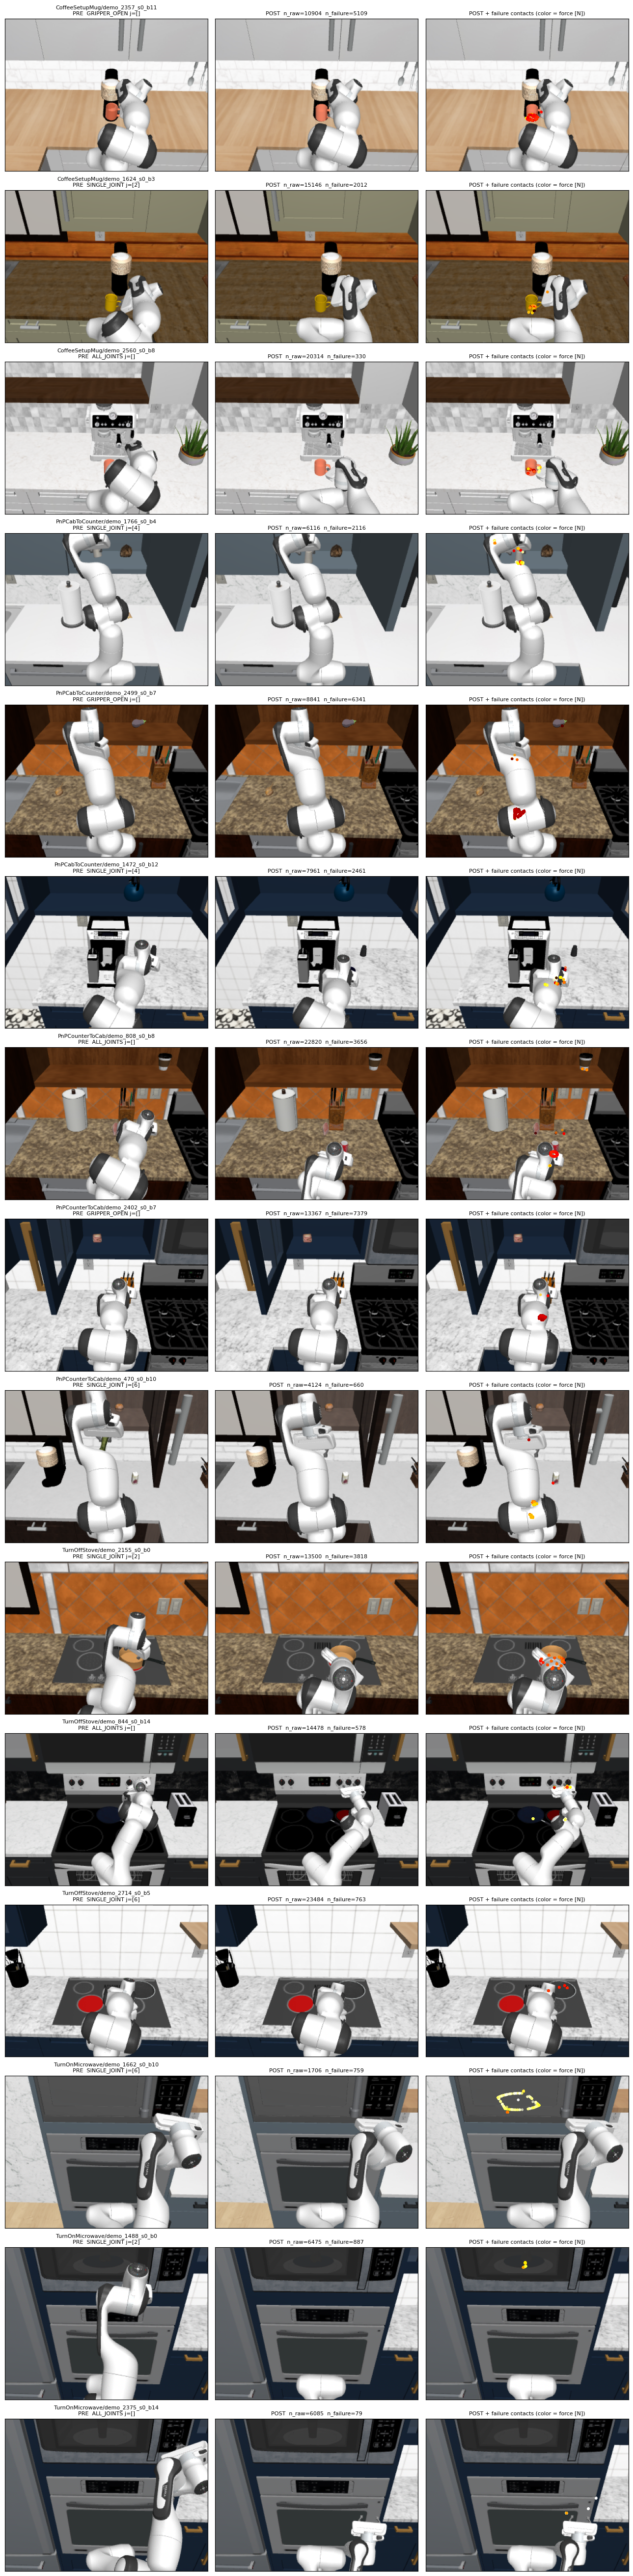

In [3]:
N_PER_TASK = 3
fig, axes = plt.subplots(len(RC_TASKS) * N_PER_TASK, 3,
                         figsize=(13, 3.5 * len(RC_TASKS) * N_PER_TASK))
for ti, task in enumerate(RC_TASKS):
    with h5py.File(RC_V2 / f"{task}.h5", "r") as f:
        # Pick trials with non-trivial failure contacts
        tids = list(f["trials"].keys())
        chosen = []
        for tid in random.sample(tids, k=min(50, len(tids))):
            g = f[f"trials/{tid}"]
            n_raw = g["contact_positions"].shape[0]
            n_base = g["baseline_contact_positions"].shape[0]
            if n_raw - n_base > 100:   # at least 100 failure-induced contacts
                chosen.append(tid)
            if len(chosen) == N_PER_TASK:
                break
        if len(chosen) < N_PER_TASK:
            chosen += random.sample([t for t in tids if t not in chosen],
                                    N_PER_TASK - len(chosen))

    for k, tid in enumerate(chosen):
        row = ti * N_PER_TASK + k
        trial = load_trial(RC_V2 / f"{task}.h5", tid)
        cp = trial["contact_positions"]
        bp = trial["baseline_contact_positions"]
        bgp = trial["baseline_contact_geom_pairs"]
        cgp = trial["contact_geom_pairs"]
        keep = filter_failure_only(cgp, cp, bgp, bp)
        cp_fail = cp[keep]
        pixels, depths, img_size = project_world_to_pixels(trial, cp_fail)

        mode = trial["failure_mode"]
        joints = trial["failure_joints"].tolist()
        n_raw = len(cp); n_fail = len(cp_fail)

        axes[row, 0].imshow(trial["pre_rgb"])
        axes[row, 0].set_title(f"{task}/{tid}\nPRE  {mode} j={joints}",
                                fontsize=8)
        axes[row, 1].imshow(trial["post_agentview_rgb"])
        axes[row, 1].set_title(f"POST  n_raw={n_raw}  n_failure={n_fail}",
                                fontsize=8)
        axes[row, 2].imshow(trial["post_agentview_rgb"])
        valid = (depths > 0) & (pixels[:, 0] >= 0) & (pixels[:, 0] < img_size[0])                 & (pixels[:, 1] >= 0) & (pixels[:, 1] < img_size[1])
        if valid.any():
            axes[row, 2].scatter(pixels[valid, 0], pixels[valid, 1],
                                 c=np.linalg.norm(trial["contact_force_world"][keep][valid], axis=1),
                                 cmap="hot", s=15, alpha=0.7, edgecolors="none",
                                 norm=LogNorm(vmin=1.0, vmax=200.0))
        axes[row, 2].set_title(f"POST + failure contacts (color = force [N])",
                                fontsize=8)
        for c in range(3):
            axes[row, c].set_xticks([]); axes[row, c].set_yticks([])

plt.tight_layout(); plt.show()


## 2. One demo, multiple failure modes

Pick a single demo from one task. Show how 4 different failure modes
produce different contact patterns.


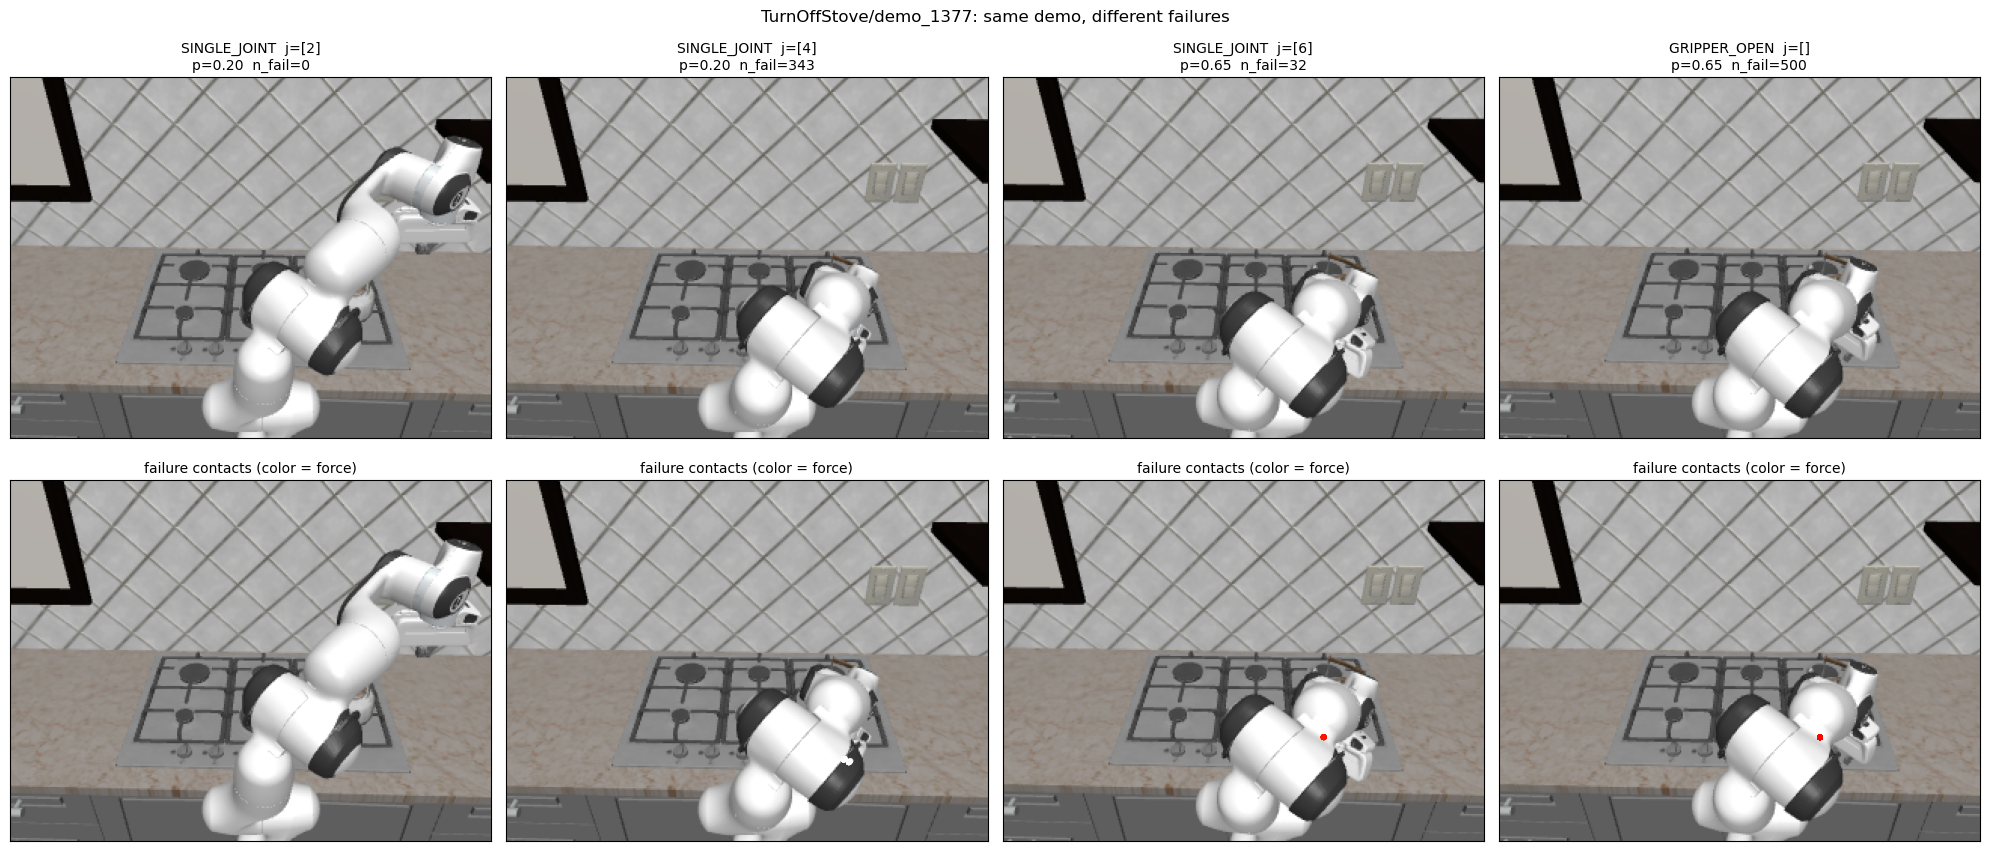

In [4]:
task = "TurnOffStove"
with h5py.File(RC_V2 / f"{task}.h5", "r") as f:
    tids = list(f["trials"].keys())
    # Pick a demo with all 4 mode variants
    demos = {}
    for tid in tids:
        dkey, _ = tid.rsplit("_s", 1)
        demos.setdefault(dkey, []).append(tid)
    demo_key = random.choice([d for d, ts in demos.items() if len(ts) >= 4])
    chosen_tids = demos[demo_key][:4]

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for col, tid in enumerate(chosen_tids):
    trial = load_trial(RC_V2 / f"{task}.h5", tid)
    cp = trial["contact_positions"]
    bp = trial["baseline_contact_positions"]
    bgp = trial["baseline_contact_geom_pairs"]
    cgp = trial["contact_geom_pairs"]
    keep = filter_failure_only(cgp, cp, bgp, bp)
    cp_fail = cp[keep]
    fw_fail = trial["contact_force_world"][keep]
    pixels, depths, img_size = project_world_to_pixels(trial, cp_fail)
    mode = trial["failure_mode"]
    joints = trial["failure_joints"].tolist()
    prog = trial["traj_progress"]
    axes[0, col].imshow(trial["post_agentview_rgb"])
    axes[0, col].set_title(f"{mode}  j={joints}\np={prog:.2f}  n_fail={len(cp_fail)}",
                           fontsize=10)
    axes[0, col].set_xticks([]); axes[0, col].set_yticks([])
    axes[1, col].imshow(trial["post_agentview_rgb"])
    valid = (depths > 0) & (pixels[:, 0] >= 0) & (pixels[:, 0] < img_size[0]) \
            & (pixels[:, 1] >= 0) & (pixels[:, 1] < img_size[1])
    if valid.any():
        axes[1, col].scatter(pixels[valid, 0], pixels[valid, 1],
                              c=np.linalg.norm(fw_fail[valid], axis=1),
                              cmap="hot", s=18, alpha=0.7, edgecolors="none",
                              norm=LogNorm(vmin=1.0, vmax=200.0))
    axes[1, col].set_title("failure contacts (color = force)", fontsize=10)
    axes[1, col].set_xticks([]); axes[1, col].set_yticks([])
fig.suptitle(f"{task}/{demo_key}: same demo, different failures", fontsize=12)
plt.tight_layout(); plt.show()


## 3. One demo + mode, sweep over progress

Same demo, same failure mode (SINGLE_JOINT j4), varying `fail_progress`.
Earlier failures hit the kitchen during transport; later failures hit
during the placement phase.


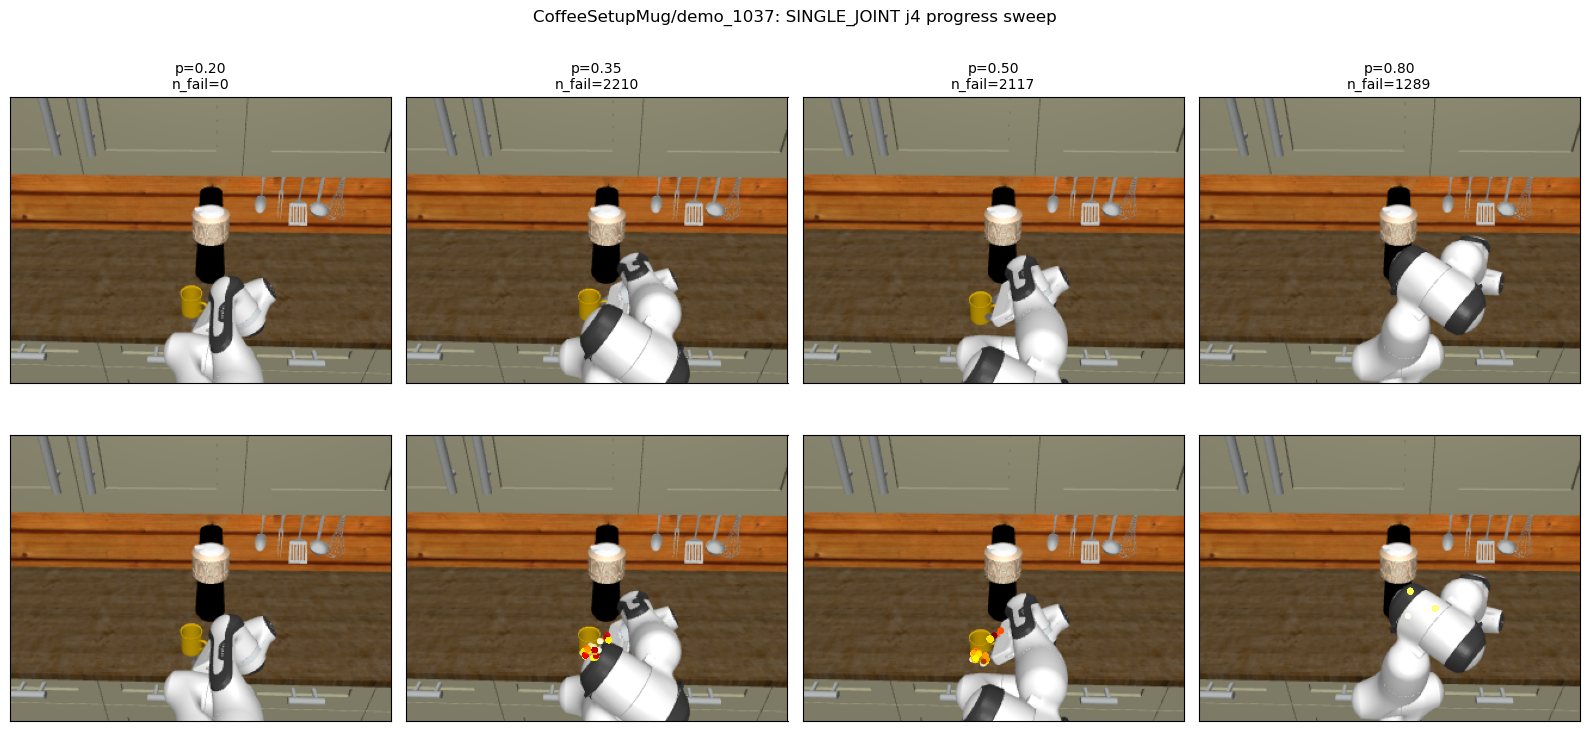

In [5]:
target_mode = "SINGLE_JOINT"
target_joints = "joint4"
for task in RC_TASKS:
    with h5py.File(RC_V2 / f"{task}.h5", "r") as f:
        tids = list(f["trials"].keys())
        by_demo = {}
        for tid in tids:
            dkey, _ = tid.rsplit("_s", 1)
            by_demo.setdefault(dkey, []).append(tid)
        # Find demo with multiple j4 progress points
        target_demo = None
        for dkey, ts in by_demo.items():
            matches = []
            for tid in ts:
                a = f[f"trials/{tid}"].attrs
                if a["failure_mode"] == target_mode and                    tid.endswith(("_b1", "_b4", "_b6", "_b12")):  # j4 bins in TIER1
                    matches.append((float(a["traj_progress"]), tid))
            if len(matches) >= 3:
                target_demo = (dkey, sorted(matches))
                break
        if target_demo is None:
            continue
    dkey, progress_tids = target_demo
    chosen_tids = [t for _, t in progress_tids][:5]
    break

fig, axes = plt.subplots(2, len(chosen_tids), figsize=(4 * len(chosen_tids), 8))
for col, tid in enumerate(chosen_tids):
    trial = load_trial(RC_V2 / f"{task}.h5", tid)
    cp = trial["contact_positions"]
    bp = trial["baseline_contact_positions"]
    bgp = trial["baseline_contact_geom_pairs"]
    cgp = trial["contact_geom_pairs"]
    keep = filter_failure_only(cgp, cp, bgp, bp)
    cp_fail = cp[keep]
    fw_fail = trial["contact_force_world"][keep]
    pixels, depths, img_size = project_world_to_pixels(trial, cp_fail)
    axes[0, col].imshow(trial["post_agentview_rgb"])
    axes[0, col].set_title(f"p={trial['traj_progress']:.2f}\nn_fail={len(cp_fail)}",
                           fontsize=10)
    axes[0, col].set_xticks([]); axes[0, col].set_yticks([])
    axes[1, col].imshow(trial["post_agentview_rgb"])
    valid = (depths > 0) & (pixels[:, 0] >= 0) & (pixels[:, 0] < img_size[0]) \
            & (pixels[:, 1] >= 0) & (pixels[:, 1] < img_size[1])
    if valid.any():
        axes[1, col].scatter(pixels[valid, 0], pixels[valid, 1],
                              c=np.linalg.norm(fw_fail[valid], axis=1),
                              cmap="hot", s=18, alpha=0.7, edgecolors="none",
                              norm=LogNorm(vmin=1.0, vmax=200.0))
    axes[1, col].set_xticks([]); axes[1, col].set_yticks([])
fig.suptitle(f"{task}/{dkey}: {target_mode} j4 progress sweep", fontsize=12)
plt.tight_layout(); plt.show()


## 4. Top-down spatial distribution per task

Aggregate failure contacts across 200 trials per task; bin onto a top-down XY
grid (above the per-trial `scene_table_z`). Shows the spatial coverage of the
contact labels per task — where in the kitchen the model needs to predict
contacts.


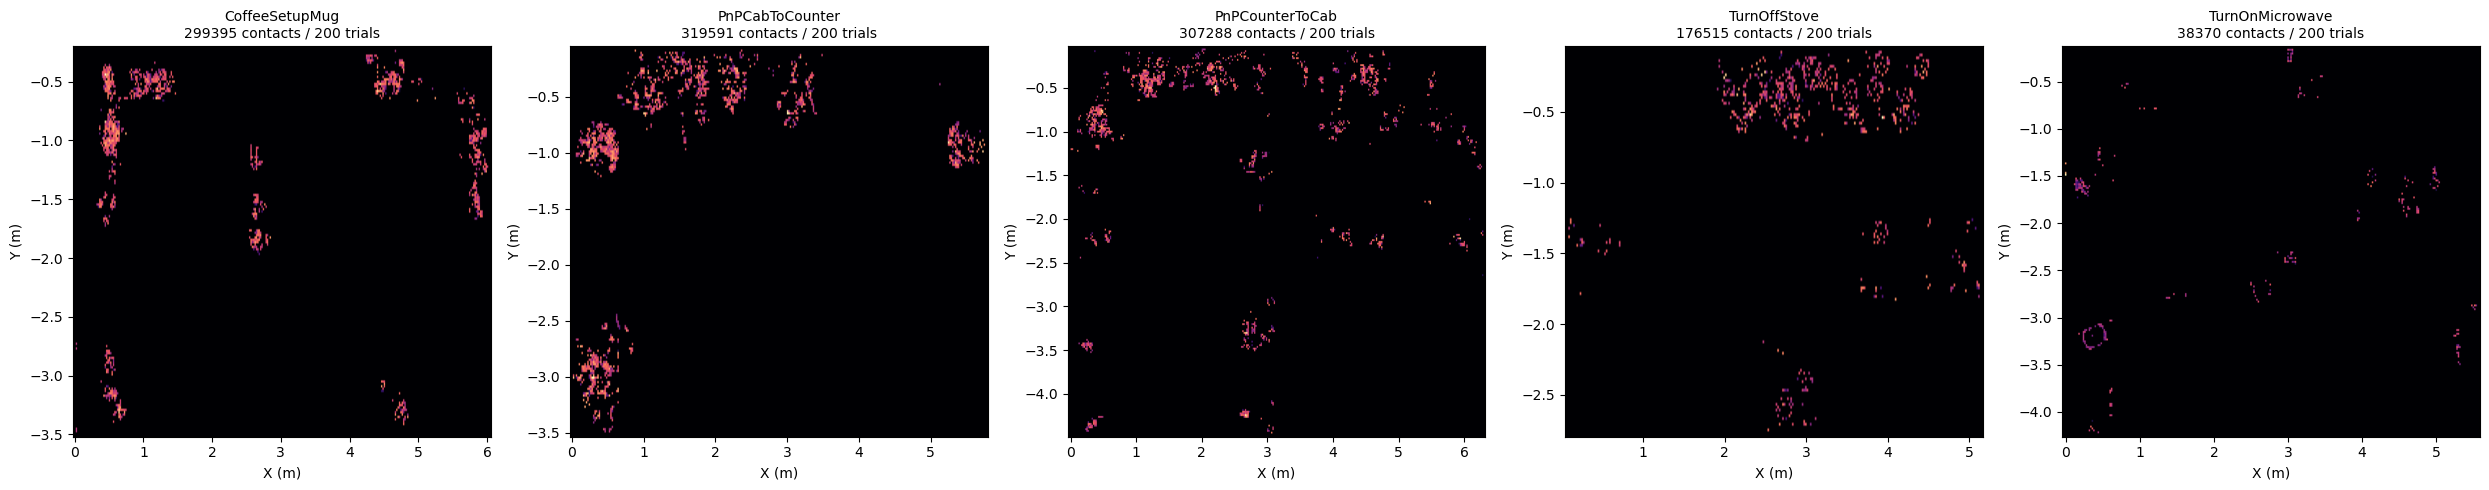

In [6]:
fig, axes = plt.subplots(1, len(RC_TASKS), figsize=(5 * len(RC_TASKS), 5))
GRID_BIN_M = 0.02   # 2 cm
for ti, task in enumerate(RC_TASKS):
    pts_all = []
    forces_all = []
    with h5py.File(RC_V2 / f"{task}.h5", "r") as f:
        tids = random.sample(list(f["trials"].keys()), k=200)
        for tid in tids:
            g = f[f"trials/{tid}"]
            cp = g["contact_positions"][...]
            if cp.shape[0] == 0: continue
            bgp = g["baseline_contact_geom_pairs"][...]
            bp = g["baseline_contact_positions"][...]
            cgp = g["contact_geom_pairs"][...]
            fw = g["contact_force_world"][...]
            keep = filter_failure_only(cgp, cp, bgp, bp)
            if not keep.any(): continue
            pts_all.append(cp[keep])
            forces_all.append(np.linalg.norm(fw[keep], axis=1))
    if not pts_all:
        axes[ti].set_title(f"{task} (no contacts)"); continue
    pts = np.concatenate(pts_all, axis=0)
    forces = np.concatenate(forces_all, axis=0)
    # 2D top-down histogram weighted by force
    x_min, y_min = pts[:, :2].min(0) - 0.05
    x_max, y_max = pts[:, :2].max(0) + 0.05
    nx = max(1, int(round((x_max - x_min) / GRID_BIN_M)))
    ny = max(1, int(round((y_max - y_min) / GRID_BIN_M)))
    H_hist, xe, ye = np.histogram2d(pts[:, 0], pts[:, 1], bins=[nx, ny],
                                     weights=forces,
                                     range=[[x_min, x_max], [y_min, y_max]])
    axes[ti].imshow(np.log1p(H_hist.T), origin='lower', extent=[x_min, x_max, y_min, y_max],
                    cmap='magma', aspect='auto')
    axes[ti].set_title(f"{task}\n{len(pts)} contacts / 200 trials", fontsize=10)
    axes[ti].set_xlabel("X (m)"); axes[ti].set_ylabel("Y (m)")
plt.tight_layout(); plt.show()


## 5. Outlier inspection

Three trials with the **most** failure contacts (likely catastrophic failures),
and three with **zero** failure contacts (failure didn't propagate).


                task         trial_id  n_failure label
205  PnPCabToCounter  demo_223_s0_b13      10138   top
668     TurnOffStove  demo_128_s0_b13       8971   top
36    CoffeeSetupMug  demo_296_s0_b10       8538   top
21    CoffeeSetupMug  demo_1196_s0_b0          0  zero
24    CoffeeSetupMug   demo_663_s0_b2          0  zero
62    CoffeeSetupMug   demo_282_s0_b3          0  zero


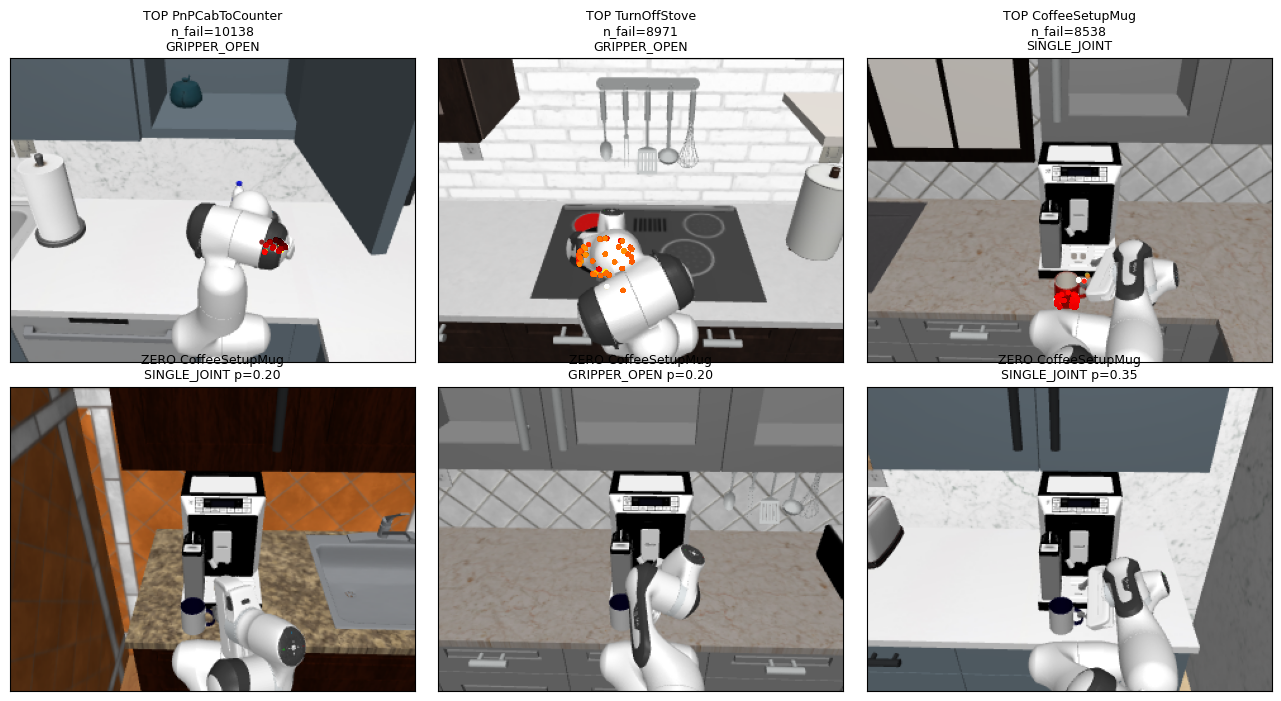

In [7]:
# Compute n_failure per trial across 200 sampled trials per task.
records = []
for task in RC_TASKS:
    with h5py.File(RC_V2 / f"{task}.h5", "r") as f:
        tids = random.sample(list(f["trials"].keys()), k=200)
        for tid in tids:
            g = f[f"trials/{tid}"]
            cp = g["contact_positions"][...]
            cgp = g["contact_geom_pairs"][...]
            bgp = g["baseline_contact_geom_pairs"][...]
            bp = g["baseline_contact_positions"][...]
            keep = filter_failure_only(cgp, cp, bgp, bp)
            records.append({
                "task": task, "trial_id": tid,
                "n_failure": int(keep.sum()),
            })
df = pd.DataFrame(records)

top3 = df.sort_values("n_failure", ascending=False).head(3)
zero = df[df["n_failure"] == 0].head(3)
panel = pd.concat([top3.assign(label="top"), zero.assign(label="zero")])
print(panel)

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for col, (_, row) in enumerate(top3.iterrows()):
    trial = load_trial(RC_V2 / f"{row['task']}.h5", row['trial_id'])
    cp = trial["contact_positions"]; cgp = trial["contact_geom_pairs"]
    bp = trial["baseline_contact_positions"]; bgp = trial["baseline_contact_geom_pairs"]
    keep = filter_failure_only(cgp, cp, bgp, bp)
    cp_fail = cp[keep]; fw_fail = trial["contact_force_world"][keep]
    pixels, depths, img_size = project_world_to_pixels(trial, cp_fail)
    axes[0, col].imshow(trial["post_agentview_rgb"])
    valid = (depths > 0) & (pixels[:, 0] >= 0) & (pixels[:, 0] < img_size[0])             & (pixels[:, 1] >= 0) & (pixels[:, 1] < img_size[1])
    if valid.any():
        axes[0, col].scatter(pixels[valid, 0], pixels[valid, 1],
                              c=np.linalg.norm(fw_fail[valid], axis=1),
                              cmap="hot", s=12, alpha=0.6, edgecolors="none",
                              norm=LogNorm(vmin=1.0, vmax=200.0))
    axes[0, col].set_title(f"TOP {row['task']}\nn_fail={row['n_failure']}\n{trial['failure_mode']}",
                           fontsize=9)
    axes[0, col].set_xticks([]); axes[0, col].set_yticks([])

if len(zero) >= 3:
    for col, (_, row) in enumerate(zero.iterrows()):
        trial = load_trial(RC_V2 / f"{row['task']}.h5", row['trial_id'])
        axes[1, col].imshow(trial["post_agentview_rgb"])
        axes[1, col].set_title(f"ZERO {row['task']}\n{trial['failure_mode']} p={trial['traj_progress']:.2f}",
                               fontsize=9)
        axes[1, col].set_xticks([]); axes[1, col].set_yticks([])
plt.tight_layout(); plt.show()


## 6. Heatmap label preview (what training sees)

Render the actual training target via `build_agentview_target` for one trial
per task. Uses the failure-induced contact subset; this is the (H, W) heatmap
the contact-prediction model is trained to regress.


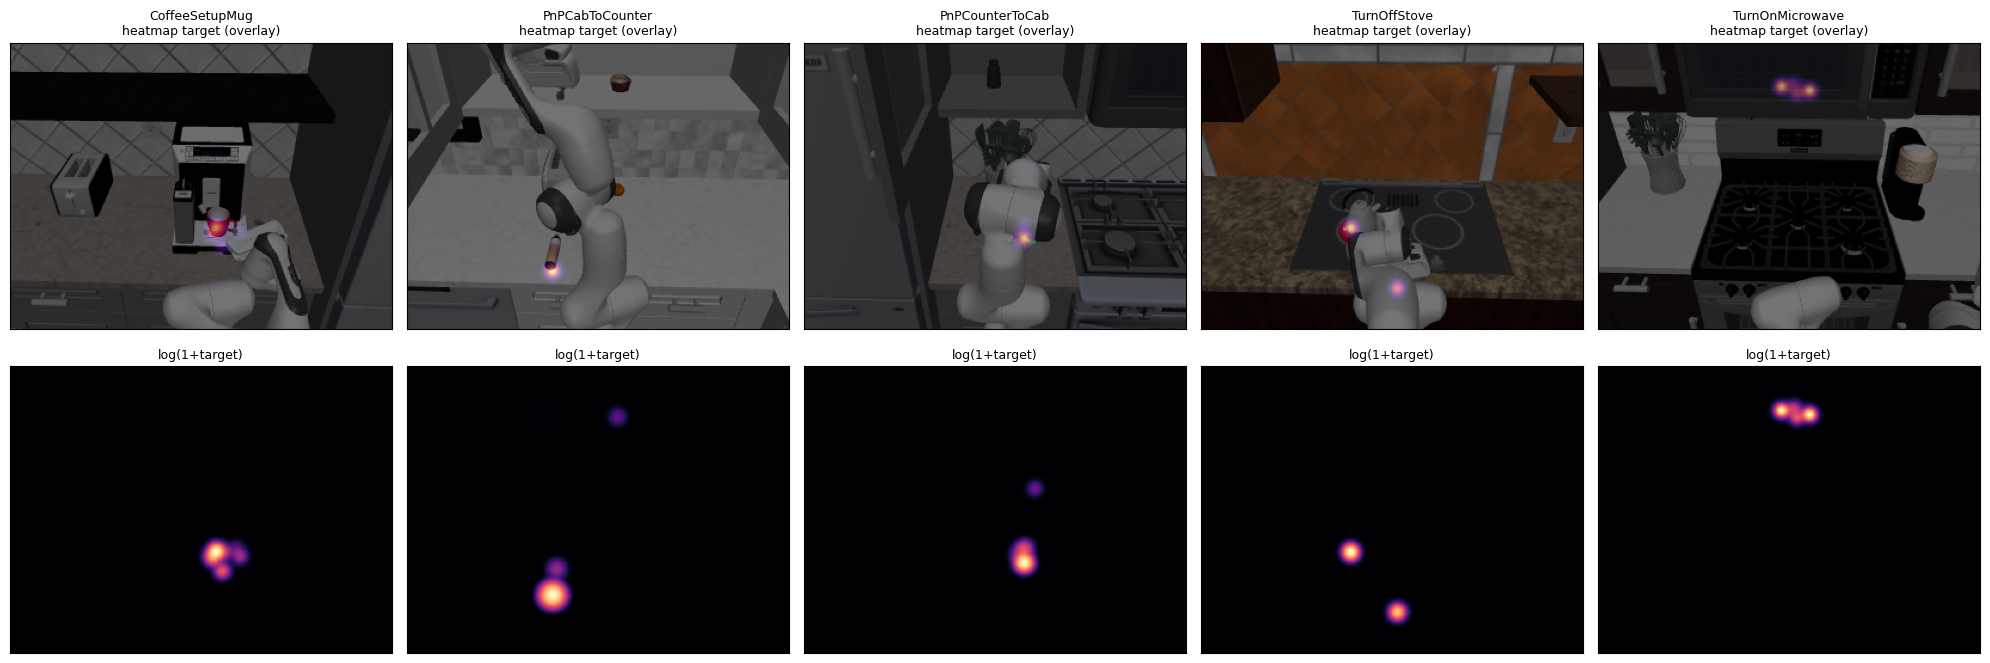

In [8]:
from planner.risk.v2_targets import build_agentview_target

fig, axes = plt.subplots(2, len(RC_TASKS), figsize=(4 * len(RC_TASKS), 7))
for ti, task in enumerate(RC_TASKS):
    with h5py.File(RC_V2 / f"{task}.h5", "r") as f:
        for tid in random.sample(list(f["trials"].keys()), k=20):
            g = f[f"trials/{tid}"]
            cp = g["contact_positions"][...]
            cgp = g["contact_geom_pairs"][...]
            bp = g["baseline_contact_positions"][...]
            bgp = g["baseline_contact_geom_pairs"][...]
            keep = filter_failure_only(cgp, cp, bgp, bp)
            if keep.sum() < 50: continue
            trial = load_trial(RC_V2 / f"{task}.h5", tid)
            # Substitute filtered contacts before building the target
            trial["contact_positions"] = cp[keep]
            trial["contact_forces"] = trial["contact_forces"][keep]
            trial["contact_force_world"] = trial["contact_force_world"][keep]
            trial["contact_geom_pairs"] = cgp[keep]
            tgt = build_agentview_target(trial, sigma_px=4.0, weighting="force_prior")
            axes[0, ti].imshow(trial["post_agentview_rgb"])
            axes[0, ti].imshow(tgt.heatmap, alpha=0.55, cmap="magma")
            axes[0, ti].set_title(f"{task}\nheatmap target (overlay)", fontsize=9)
            axes[0, ti].set_xticks([]); axes[0, ti].set_yticks([])
            axes[1, ti].imshow(np.log1p(tgt.heatmap), cmap="magma")
            axes[1, ti].set_title("log(1+target)", fontsize=9)
            axes[1, ti].set_xticks([]); axes[1, ti].set_yticks([])
            break
plt.tight_layout(); plt.show()


## 7. Per-task failure-contact count distribution

Histogram of `n_failure_contacts` per task (after baseline subtraction).
Shows which tasks have the densest labels — useful for class-imbalanced
sampling at training time.


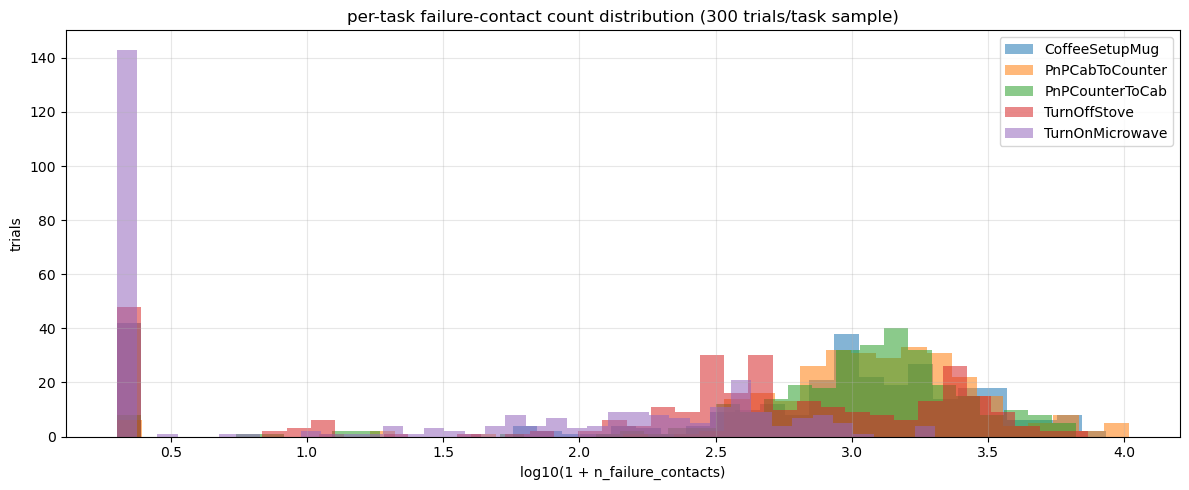

                 count         mean          std  min     25%     50%  \
task                                                                    
CoffeeSetupMug   300.0  1447.033333  1493.096696  0.0  409.25   999.0   
PnPCabToCounter  300.0  1725.990000  1638.047889  0.0  762.00  1284.5   
PnPCounterToCab  300.0  1482.326667  1208.535547  0.0  689.50  1233.0   
TurnOffStove     300.0   978.583333  1226.807714  0.0  173.25   447.5   
TurnOnMicrowave  300.0   176.606667   315.341677  0.0    0.00    15.0   

                     75%      max  
task                               
CoffeeSetupMug   1950.50   8590.0  
PnPCabToCounter  2120.75  10426.0  
PnPCounterToCab  1835.50   6632.0  
TurnOffStove     1716.25   7372.0  
TurnOnMicrowave   247.00   2023.0  


In [9]:
records = []
for task in RC_TASKS:
    with h5py.File(RC_V2 / f"{task}.h5", "r") as f:
        for tid in random.sample(list(f["trials"].keys()), k=300):
            g = f[f"trials/{tid}"]
            cp = g["contact_positions"][...]
            cgp = g["contact_geom_pairs"][...]
            bp = g["baseline_contact_positions"][...]
            bgp = g["baseline_contact_geom_pairs"][...]
            keep = filter_failure_only(cgp, cp, bgp, bp)
            records.append({"task": task, "n_failure": int(keep.sum())})
df = pd.DataFrame(records)

fig, ax = plt.subplots(figsize=(12, 5))
for task in RC_TASKS:
    sub = df[df["task"] == task]["n_failure"]
    ax.hist(np.log10(sub.clip(1) + 1), bins=40, alpha=0.55, label=task)
ax.set_xlabel("log10(1 + n_failure_contacts)")
ax.set_ylabel("trials")
ax.set_title("per-task failure-contact count distribution (300 trials/task sample)")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(df.groupby("task")["n_failure"].describe())
